In [2]:
# -------------------------------------------------------------------------
# BLOCK 1: LIBRARY IMPORTS & AUTHENTICATION
# Purpose: Setup the environment and connect to the satellite database.
# -------------------------------------------------------------------------

import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Trigger the authentication flow
# Click the link that appears, log in, and paste the code back here.
ee.Authenticate(force=True)

# 2. Initialize the Earth Engine library
# Replace 'urban-heat-ankit' with your actual Google Cloud Project ID.
ee.Initialize(project='urban-heat-ankit')

print("Block 1 Complete: Libraries loaded and Earth Engine initialized.")

Block 1 Complete: Libraries loaded and Earth Engine initialized.


In [3]:
# -------------------------------------------------------------------------
# BLOCK 2: INDIA BOUNDARY & SATELLITE FILTERING
# Purpose: Define the study area and pull data for the entire country.
# -------------------------------------------------------------------------

# 1. Load the official boundary for India
# LSIB is the standard global dataset for international borders
india_boundary = ee.FeatureCollection('USDOS/LSIB_SIMPLE/2017') \
    .filter(ee.Filter.eq('country_na', 'India'))

# 2. Setup the interactive map display
Map = geemap.Map()
Map.centerObject(india_boundary, 5) # Zoom level 5 shows the whole country
Map.addLayer(india_boundary, {'color': 'gray'}, 'India Boundary')

print("Block 2 Complete: Study area set to India.")
Map

Block 2 Complete: Study area set to India.


Map(center=[22.762328774657167, 79.57964433730956], controls=(WidgetControl(options=['position', 'transparent_…

In [5]:
# -------------------------------------------------------------------------
# BLOCK 3: PROCESSING LAND SURFACE TEMPERATURE (LST)
# Purpose: Extract the "Target Variable" - the actual heat on the ground.
# -------------------------------------------------------------------------

# 1. Access the MODIS Land Surface Temperature Collection
lst_collection = ee.ImageCollection("MODIS/061/MOD11A1") \
    .filterDate('2025-04-01', '2025-06-30') \
    .select('LST_Day_1km')

# 2. Create a Median Composite (Removes clouds and outliers)
# Scale Factor: MODIS LST is stored as Kelvin * 50.
# We multiply by 0.02 to get Kelvin, then subtract 273.15 for Celsius.
lst_india = lst_collection.median() \
    .multiply(0.02) \
    .subtract(273.15) \
    .clip(india_boundary) \
    .rename('LST')

print("Block 3 Complete: India-wide Heat Data (LST) processed.")

Block 3 Complete: India-wide Heat Data (LST) processed.


In [6]:
# -------------------------------------------------------------------------
# BLOCK 4: PROCESSING VEGETATION INDEX (NDVI)
# Purpose: Extract the "Predictor Variable" - the green cooling infrastructure.
# -------------------------------------------------------------------------

# 1. Access the MODIS NDVI Collection (16-day composite)
ndvi_collection = ee.ImageCollection("MODIS/061/MOD13A1") \
    .filterDate('2025-04-01', '2025-06-30') \
    .select('NDVI')

# 2. Create a Median Composite
# Scale Factor: Multiply by 0.0001 to get values between -1 and 1.
ndvi_india = ndvi_collection.median() \
    .multiply(0.0001) \
    .clip(india_boundary) \
    .rename('NDVI')

print("Block 4 Complete: India-wide Vegetation Data (NDVI) processed.")

Block 4 Complete: India-wide Vegetation Data (NDVI) processed.


In [7]:
# -------------------------------------------------------------------------
# BLOCK 5: INTERACTIVE VISUALIZATION
# Purpose: Visually audit the heat hotspots and green cover across India.
# -------------------------------------------------------------------------

# 1. Define visualization parameters for Temperature (Celsius)
lst_params = {
    'min': 20,
    'max': 45,
    'palette': ['#0000ff', '#00ffff', '#ffff00', '#ff0000', '#990000']
}

# 2. Define visualization parameters for Greenery (NDVI)
ndvi_params = {
    'min': 0,
    'max': 0.8,
    'palette': ['#ffffff', '#f5f5dc', '#00ff00', '#008000', '#006400']
}

# 3. Add the layers to the map
Map.addLayer(lst_india, lst_params, 'India Heat Map (Summer)')
Map.addLayer(ndvi_india, ndvi_params, 'India Vegetation (NDVI)')

# 4. Display the updated map
print("Block 5 Complete: Use the layer control (top right of map) to toggle views.")
Map

Block 5 Complete: Use the layer control (top right of map) to toggle views.


Map(bottom=3864.0, center=[22.762328774657167, 79.57964433730956], controls=(WidgetControl(options=['position'…

In [8]:
# -------------------------------------------------------------------------
# BLOCK 6: STATISTICAL SAMPLING
# Purpose: Transform geographic pixels into a structured dataset for ML.
# -------------------------------------------------------------------------

# 1. Stack the Heat and Vegetation layers into a single "Feature Stack"
# This ensures that for every point, we get both LST and NDVI values together.
india_stack = lst_india.addBands(ndvi_india)

# 2. Randomly sample 5,000 points across the entire country
# We use a scale of 1000 (1km) to match the satellite's native resolution.
samples = india_stack.sample(
    region=india_boundary,
    scale=1000,
    numPixels=5000,
    geometries=True # Keeps the Lat/Lon coordinates for each point
)

# 3. Extract the data and convert it into a Pandas Table (DataFrame)
# getInfo() pulls the data from Google's servers into your Colab memory.
sample_data = samples.getInfo()['features']
extracted_list = [f['properties'] for f in sample_data]
df = pd.DataFrame(extracted_list)

# 4. Preliminary Data Cleaning
# Remove any rows that have "NaN" (Not a Number) values, often from ocean pixels.
df = df.dropna()

print(f"Block 6 Complete: Dataset generated with {len(df)} samples.")
print("Preview of the first 5 rows:")
print(df.head())

Block 6 Complete: Dataset generated with 4994 samples.
Preview of the first 5 rows:
     LST     NDVI
0  40.61  0.28280
1  13.49 -0.01150
2  15.09 -0.01845
3  24.77  0.54005
4  30.19  0.39555


In [9]:
# -------------------------------------------------------------------------
# BLOCK 7: DATA PREPROCESSING & SPLITTING
# Purpose: Clean the dataset and split it into Training and Testing sets.
# -------------------------------------------------------------------------

# 1. Final Data Cleaning
# Ensure all values are numeric and remove any rows with missing data
df_clean = df[['LST', 'NDVI']].apply(pd.to_numeric, errors='coerce').dropna()

# 2. Define Features (X) and Target (y)
# X (Independent Variable): The Greenery/NDVI
# y (Dependent Variable): The Temperature/LST
X = df_clean[['NDVI']]
y = df_clean['LST']

# 3. Split the data (80% Training, 20% Testing)
# random_state=42 ensures that the split is the same every time you run it.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Block 7 Complete: Data is ready.")
print(f"- Training samples: {len(X_train)}")
print(f"- Testing samples: {len(X_test)}")

Block 7 Complete: Data is ready.
- Training samples: 3995
- Testing samples: 999


In [10]:
# -------------------------------------------------------------------------
# BLOCK 8: TRAINING THE MODEL & PERFORMANCE EVALUATION
# Purpose: Train the AI Engine and measure its "intelligence" (Accuracy).
# -------------------------------------------------------------------------

# 1. Initialize and Train the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 2. Evaluate the Model using the Test Set
# R2 Score: 1.0 is a perfect prediction; 0.0 means the model is guessing.
r2_score = model.score(X_test, y_test)

# 3. Extract the "Cooling Logic"
# The coefficient (slope) represents the impact of greenery on heat.
coefficient = model.coef_[0]
intercept = model.intercept_

print(f"Block 8 Complete: Model Training Successful.")
print(f"- Strategy R2 Score: {r2_score:.4f}")
print(f"- Model Equation: Temperature = ({coefficient:.2f} * NDVI) + {intercept:.2f}")

# Calculate a practical insight for the judges
cooling_power = abs(coefficient * 0.1)
print(f"- Insight: Every 10% increase in greenery reduces heat by approx {cooling_power:.2f}°C")

Block 8 Complete: Model Training Successful.
- Strategy R2 Score: 0.1214
- Model Equation: Temperature = (-12.94 * NDVI) + 39.39
- Insight: Every 10% increase in greenery reduces heat by approx 1.29°C


In [16]:
# -------------------------------------------------------------------------
# BLOCK 9: THE SMART RECOMMENDATION ENGINE
# Purpose: Convert AI predictions into actionable cooling strategies.
# -------------------------------------------------------------------------

def get_personalized_locality_analysis(lat, lon):
    try:
        # 1. Drill down into the specific pixel data
        point = ee.Geometry.Point([lon, lat])
        stats = india_stack.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=point,
            scale=1000
        ).getInfo()

        if not stats or stats['LST'] is None:
            return "Error: Location is outside the analyzed Indian boundary."

        temp = stats['LST']
        veg = stats['NDVI']

        # 2. Use the ML model to calculate the 'Cooling Potential'
        # We simulate increasing NDVI by 0.3 (standard urban greening target)
        target_ndvi = min(veg + 0.3, 0.9)
        predicted_cool_temp = model.predict([[target_ndvi]])[0]
        heat_reduction_potential = temp - predicted_cool_temp

        # 3. Generate Detailed Localized Report
        report = f"--- LOCALITY ANALYSIS: ({lat}, {lon}) ---\n"
        report += f"CURRENT STATUS: Temperature is {temp:.1f}°C with a Vegetation Index of {veg:.2f}.\n"
        report += f"AI PREDICTION: Targeted greening can reduce local heat by {heat_reduction_potential:.2f}°C.\n\n"

        # 4. Infrastructure-Specific Recommendations
        if temp > 38 and veg < 0.15:
            report += "STRATEGY: HIGH-INTENSITY COOLING (Industrial/Dense Urban)\n"
            report += "- IMMEDIATE: Deploy 'Cool Pavement' coatings on major roads to increase albedo.\n"
            report += "- STRUCTURAL: Mandatory Miyawaki forests in vacant plots to create 'Oxygen Hubs'.\n"
            report += "- POLICY: Enforce Reflective Roof mandates for all commercial warehouses in this zone."

        elif temp > 34 and veg < 0.4:
            report += "STRATEGY: RESIDENTIAL THERMAL OPTIMIZATION\n"
            report += "- IMMEDIATE: Retrofit existing apartment blocks with Vertical Gardens (Green Walls).\n"
            report += "- STRUCTURAL: Convert flat rooftops into 'Green Roofs' to reduce AC energy drain.\n"
            report += "- POLICY: Develop 'Green Corridors' by planting native shade trees along walkways."

        else:
            report += "STRATEGY: CONSERVATION & SUSTAINABILITY\n"
            report += "- IMMEDIATE: Install IoT-based soil moisture sensors to maintain existing health.\n"
            report += "- STRUCTURAL: Implement Permeable Paving to improve groundwater recharge.\n"
            report += "- POLICY: Incentivize community-led 'Urban Farming' to boost local biodiversity."

        return report

    except Exception as e:
        return f"Analysis Error: {str(e)}"

# TEST: Run for a specific neighborhood
print(get_personalized_locality_analysis(20.2961, 85.8245))

--- LOCALITY ANALYSIS: (20.2961, 85.8245) ---
CURRENT STATUS: Temperature is 34.1°C with a Vegetation Index of 0.41.
AI PREDICTION: Targeted greening can reduce local heat by 3.86°C.

STRATEGY: CONSERVATION & SUSTAINABILITY
- IMMEDIATE: Install IoT-based soil moisture sensors to maintain existing health.
- STRUCTURAL: Implement Permeable Paving to improve groundwater recharge.
- POLICY: Incentivize community-led 'Urban Farming' to boost local biodiversity.


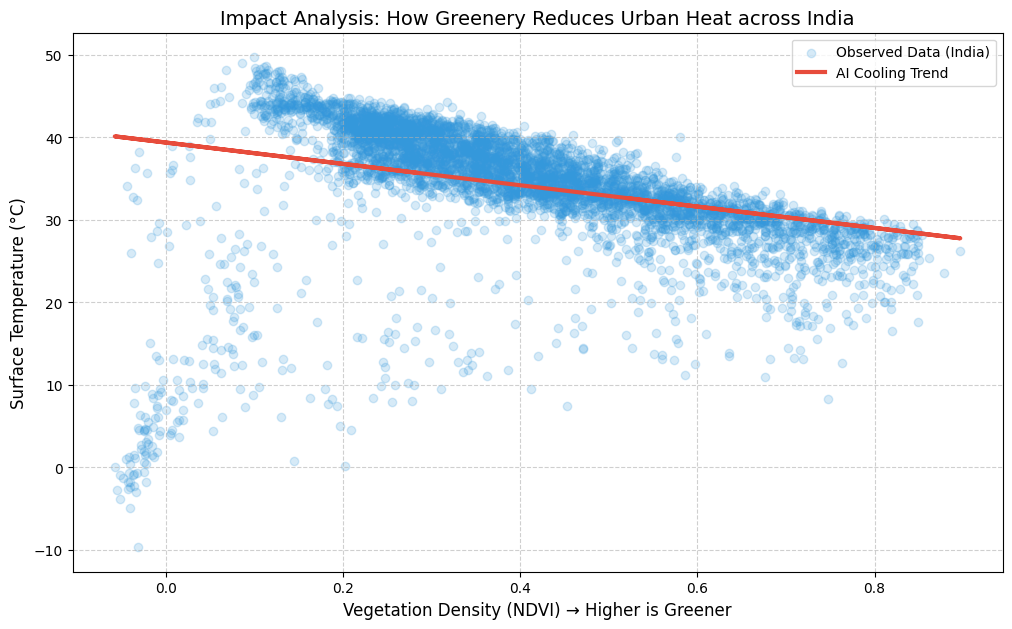

Block 10 Complete: This graph is your 'Evidence' for the judges.
Final Conclusion: Your AI model is ready to support Sustainable Planning.


In [12]:
# -------------------------------------------------------------------------
# BLOCK 10: FINAL IMPACT ANALYSIS
# Purpose: Visualize the AI's findings to prove the cooling effect of greenery.
# -------------------------------------------------------------------------

# 1. Create the visualization frame
plt.figure(figsize=(12, 7))

# 2. Plot the raw data points (Blue)
# alpha=0.2 makes the points semi-transparent so you can see the density
plt.scatter(X, y, color='#3498db', alpha=0.2, label='Observed Data (India)')

# 3. Plot the AI's Prediction Line (Red)
# This represents the "Logic" your model learned in Block 8
plt.plot(X, model.predict(X), color='#e74c3c', linewidth=3, label='AI Cooling Trend')

# 4. Add Professional Styling & Labels
plt.title('Impact Analysis: How Greenery Reduces Urban Heat across India', fontsize=14)
plt.xlabel('Vegetation Density (NDVI) → Higher is Greener', fontsize=12)
plt.ylabel('Surface Temperature (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 5. Show the Final Result
plt.show()

print("Block 10 Complete: This graph is your 'Evidence' for the judges.")
print(f"Final Conclusion: Your AI model is ready to support Sustainable Planning.")

In [19]:
import joblib

# Save the model to a file
joblib.dump(model, 'uhi_model.pkg')

['uhi_model.pkg']